# Coincidence timing comparison

This notebook finds every parameter-scan ROOT file automatically and compares `dt_peak_ticks_coinc`, `dt_peak_ticks_save`, and `saved_channel`. Only the three requested scalar branches are read; the large `adc` waveform branch is not loaded.

In [1]:
from pathlib import Path
import re

import matplotlib.pyplot as plt
import numpy as np
import ROOT



# Works when Jupyter starts either in the repository root or in analysis/.
FILE_PATTERN = "coincident_wfs_m7_m8_window_50_ticks_coinc_adc_*_save_adc_*.root"
candidate_dirs = (Path.cwd(), Path.cwd() / "analysis")
DATA_DIR = next((d for d in candidate_dirs if any(d.glob(FILE_PATTERN))), None)
if DATA_DIR is None:
    raise FileNotFoundError(f"No parameter-scan ROOT files found below {Path.cwd()}")

filename_re = re.compile(
    r"^coincident_wfs_m7_m8_window_(?P<window>\d+)_ticks_"
    r"coinc_adc_(?P<coinc_adc>\d+)_save_adc_(?P<save_adc>\d+)\.root$"
)

file_info = []
for path in DATA_DIR.glob(FILE_PATTERN):
    match = filename_re.fullmatch(path.name)
    if match:
        parameters = {name: int(value) for name, value in match.groupdict().items()}
        file_info.append({"path": path, **parameters})

file_info.sort(key=lambda item: (item["window"], item["coinc_adc"], item["save_adc"]))
print(f"Found {len(file_info)} files in {DATA_DIR.resolve()}")
if not file_info:
    raise RuntimeError("Files matched the glob, but their parameter labels could not be parsed")


/home/leoperes/.local/lib/python3.12/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


Found 12 files in /home/leoperes/sag_analysis/analysis


In [2]:
TREE_NAME = "CoincidentWaveforms"
BRANCHES = ["dt_peak_ticks_coinc", "dt_peak_ticks_save", "saved_channel"]

datasets = []
for info in file_info:
    # RDataFrame reads only these columns and does not materialize the adc vectors.
    arrays = ROOT.RDataFrame(TREE_NAME, str(info["path"])).AsNumpy(BRANCHES)
    datasets.append({**info, **arrays})

print(f"Loaded {len(datasets)} datasets ({sum(len(d['saved_channel']) for d in datasets):,} rows)")


Loaded 12 datasets (2,005,528 rows)


In [3]:
# Set this to False to compare raw entry counts instead of distribution shapes.
NORMALIZE = False

amplitude_pairs = sorted({(d["coinc_adc"], d["save_adc"]) for d in datasets})
colors = {pair: plt.cm.turbo(x) for pair, x in zip(amplitude_pairs, np.linspace(0, 1, len(amplitude_pairs)))}
windows = sorted({d["window"] for d in datasets})
channels = sorted({int(channel) for d in datasets for channel in np.unique(d["saved_channel"])})

def label_for(d):
    return (f"coinc={d['coinc_adc']}, "
            f"save={d['save_adc']}")

def overlay_histograms_by_window(branch, bins, xlabel, title, *, integer_ticks=False):
    plots = {}
    for window in windows:
        window_bins = bins(window) if callable(bins) else bins
        fig, ax = plt.subplots(dpi=150)
        for d in (item for item in datasets if item["window"] == window):
            pair = (d["coinc_adc"], d["save_adc"])
            ax.hist(
                d[branch], bins=window_bins, histtype="step", density=NORMALIZE,
                linewidth=1.8, color=colors[pair], label=label_for(d),
            )
            ax.grid()

        ax.set_xlabel(xlabel, fontsize=14)
        ax.set(
            ylabel="Probability density" if NORMALIZE else "Entries",
            title=f"{title} — {window}-tick window",
        )
        if integer_ticks:
            centers = (np.asarray(window_bins[:-1]) + np.asarray(window_bins[1:])) / 2
            if len(centers) <= 25:
                ax.set_xticks(centers.astype(int))
        ax.legend(title = "ADC",loc="upper left", fontsize=8, frameon=False)
        fig.tight_layout()
        plots[window] = (fig, ax)
    return plots

def overlay_histograms_by_window_and_channel(branch, bins, xlabel, title, *, integer_ticks=False):
    plots = {}
    ncols = 2
    nrows = int(np.ceil(len(channels) / ncols))

    for window in windows:
        window_bins = bins(window) if callable(bins) else bins
        fig, axes = plt.subplots(
            nrows, ncols, figsize=(12, 4 * nrows), dpi=150,
            sharex=True, squeeze=False,
        )

        for ax, channel in zip(axes.flat, channels):
            for d in (item for item in datasets if item["window"] == window):
                pair = (d["coinc_adc"], d["save_adc"])
                channel_values = d[branch][d["saved_channel"] == channel]
                ax.hist(
                    channel_values, bins=window_bins, histtype="step",
                    density=NORMALIZE, linewidth=1.6, color=colors[pair],
                    label=label_for(d),
                )

            ax.set(
                xlabel=xlabel,
                ylabel="Probability density" if NORMALIZE else "Entries",
                title=f"Saved channel {channel}",
            )
            ax.grid(alpha=0.3)
            if integer_ticks:
                centers = (np.asarray(window_bins[:-1]) + np.asarray(window_bins[1:])) / 2
                if len(centers) <= 25:
                    ax.set_xticks(centers.astype(int))

        for ax in axes.flat[len(channels):]:
            ax.set_visible(False)

        handles, labels = axes.flat[0].get_legend_handles_labels()
        fig.legend(
            handles, labels, title="ADC", loc="center left",
            bbox_to_anchor=(0.83, 0.5), fontsize=8, frameon=False,
        )
        fig.suptitle(f"{title} — {window}-tick window")
        fig.tight_layout(rect=(0, 0, 0.82, 0.95))
        plots[window] = (fig, axes)

    return plots


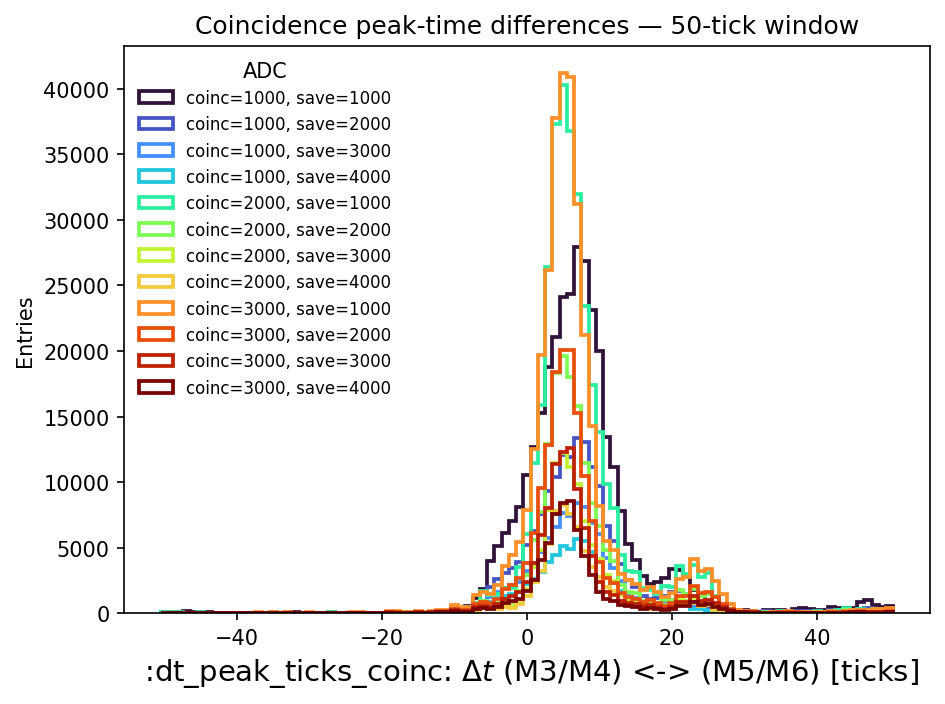

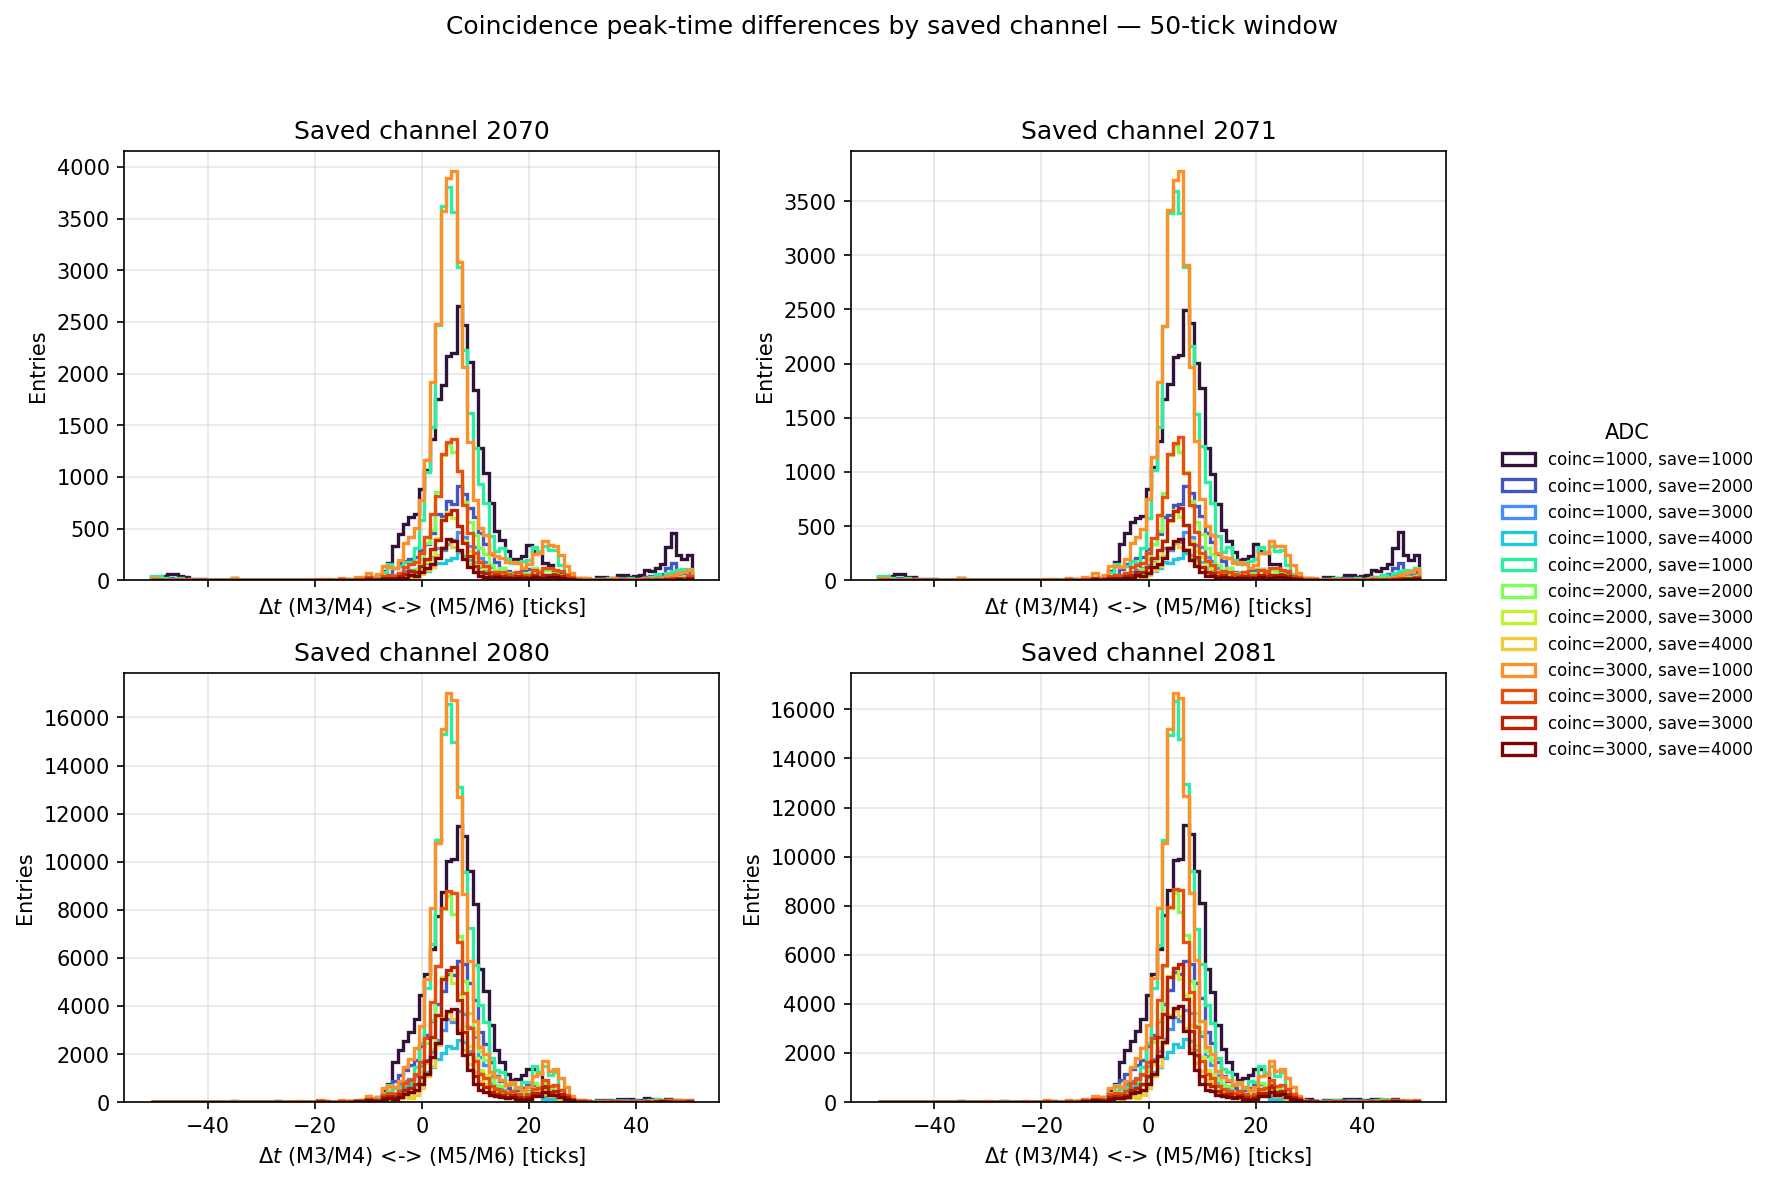

In [4]:
dt_bins = lambda window: np.arange(-window - 0.5, window + 1.5, 1)
coinc_plots = overlay_histograms_by_window(
    "dt_peak_ticks_coinc", dt_bins,
    r" :dt_peak_ticks_coinc: $\Delta t$ (M3/M4) <-> (M5/M6) [ticks]",
    "Coincidence peak-time differences",
)

coinc_channel_plots = overlay_histograms_by_window_and_channel(
    "dt_peak_ticks_coinc", dt_bins,
    r"$\Delta t$ (M3/M4) <-> (M5/M6) [ticks]",
    "Coincidence peak-time differences by saved channel",
)


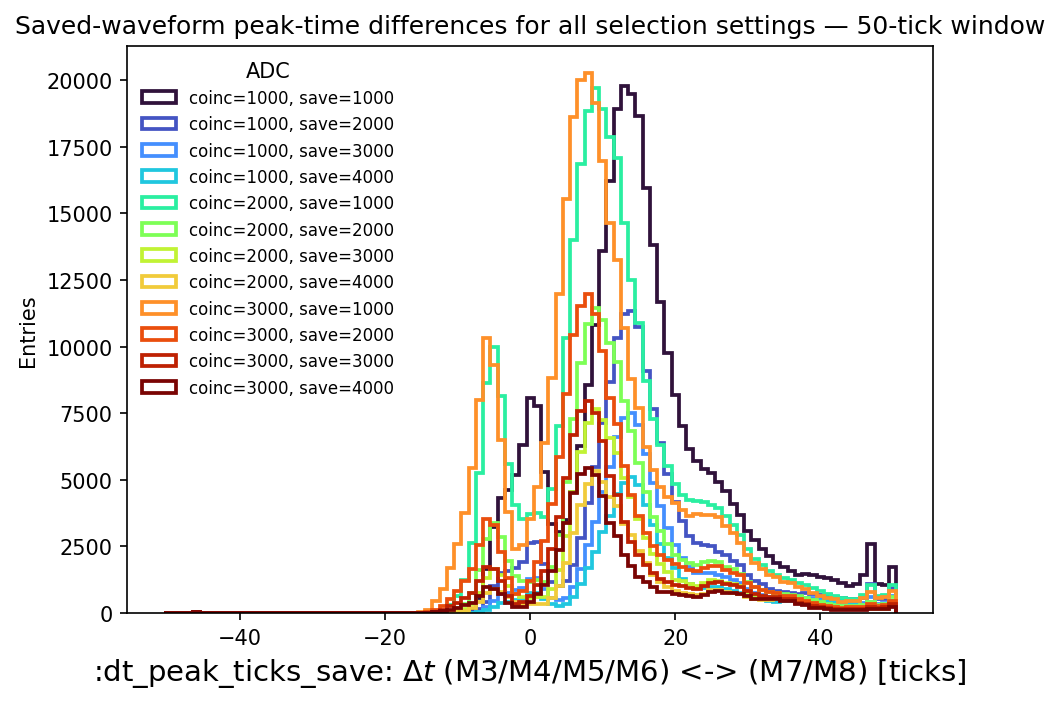

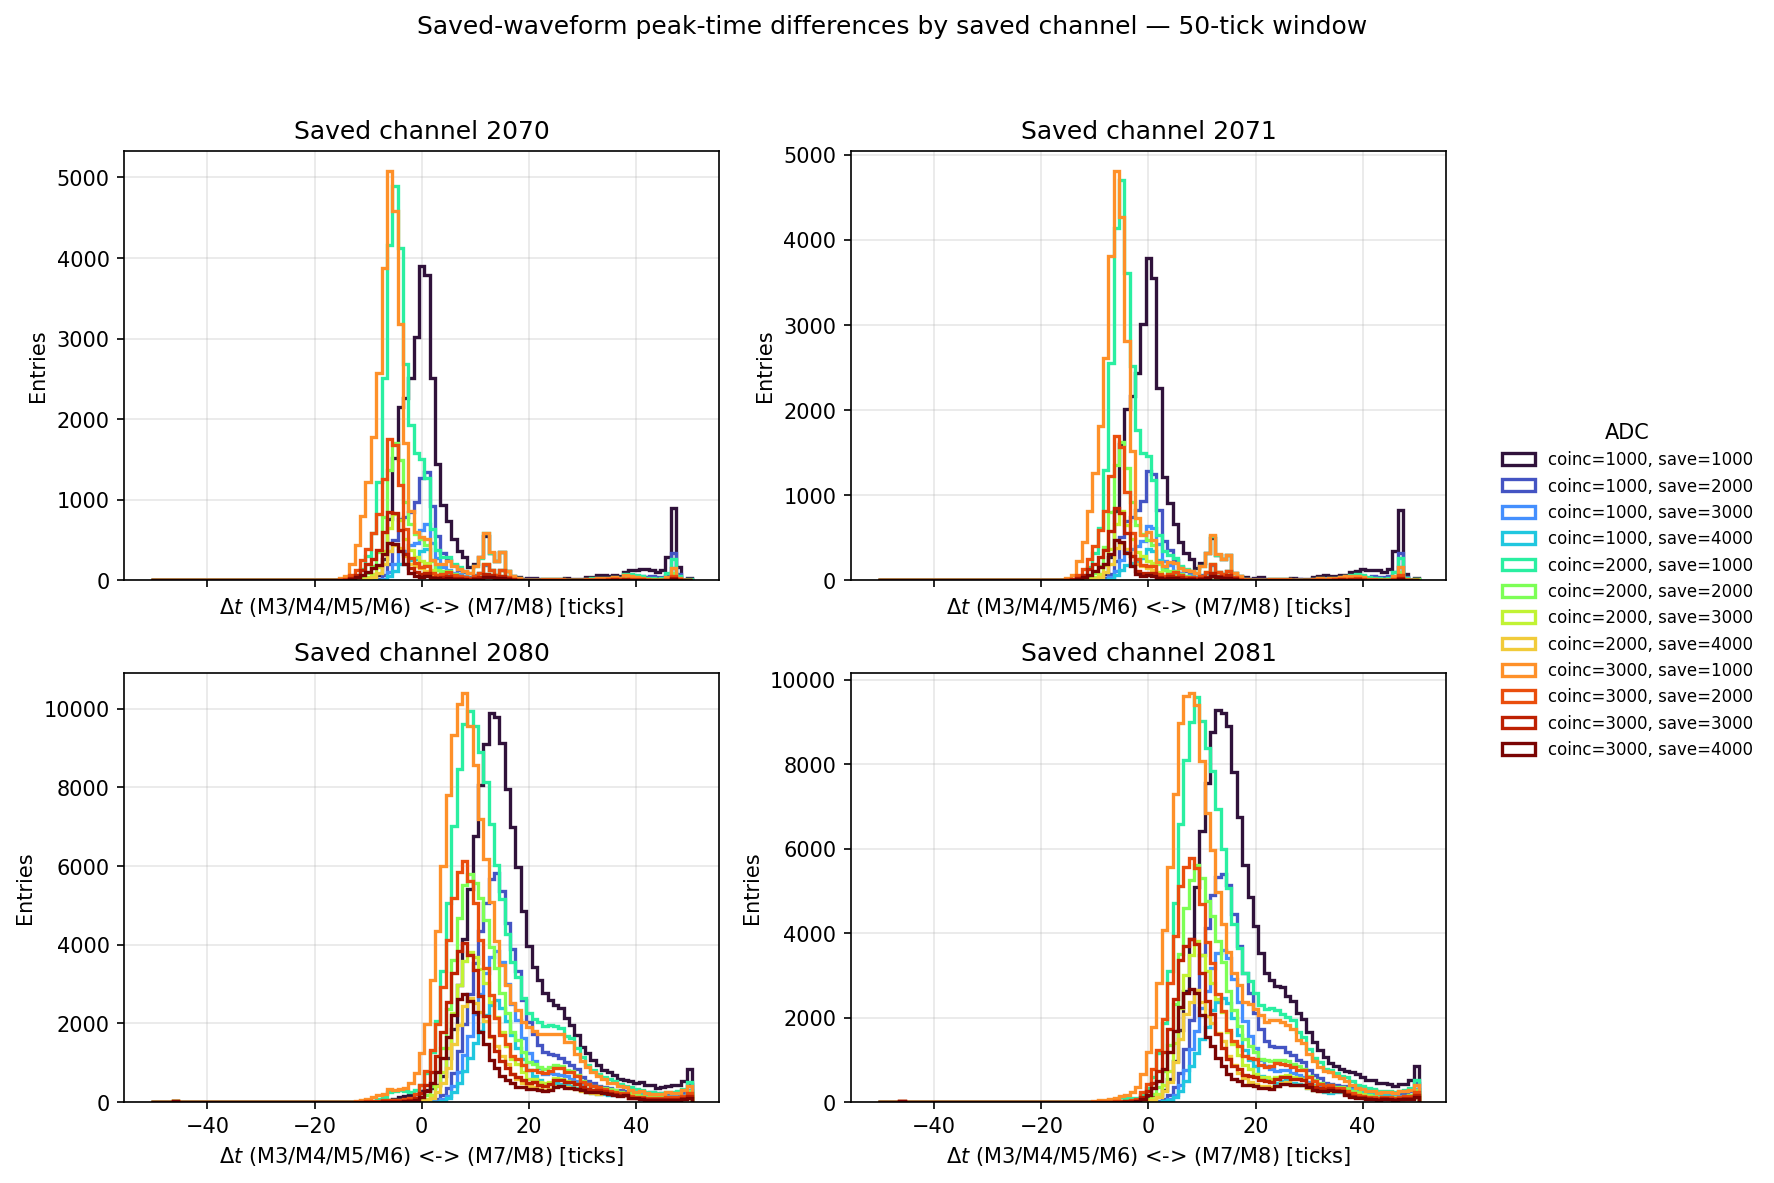

In [5]:
save_dt_plots = overlay_histograms_by_window(
    "dt_peak_ticks_save", dt_bins,
    r":dt_peak_ticks_save: $\Delta t$ (M3/M4/M5/M6) <-> (M7/M8) [ticks]",
    "Saved-waveform peak-time differences for all selection settings",
)

save_dt_channel_plots = overlay_histograms_by_window_and_channel(
    "dt_peak_ticks_save", dt_bins,
    r"$\Delta t$ (M3/M4/M5/M6) <-> (M7/M8) [ticks]",
    "Saved-waveform peak-time differences by saved channel",
)


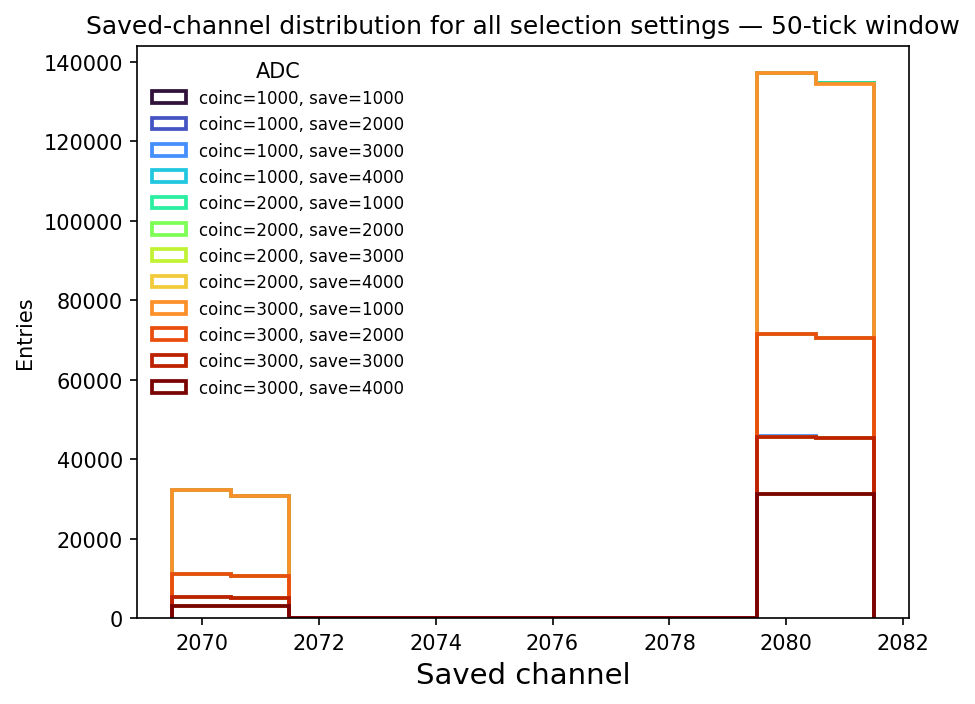

In [6]:
all_channels = np.concatenate([d["saved_channel"] for d in datasets])
channel_bins = np.arange(all_channels.min() - 0.5, all_channels.max() + 1.5, 1)
channel_plots = overlay_histograms_by_window(
    "saved_channel", channel_bins, "Saved channel",
    "Saved-channel distribution for all selection settings",
)


In [7]:
def select_discrimination(coinc_adc, save_adc, channel, plot_specs):
    """Return filtered values, a selection label, and the x-axis label."""
    valid_plot_specs = ("dt_peak_ticks_coinc", "dt_peak_ticks_save")
    if plot_specs not in valid_plot_specs:
        raise ValueError(f"plot_specs must be one of {valid_plot_specs}")

    matching_settings = [
        d for d in datasets
        if d["coinc_adc"] == coinc_adc and d["save_adc"] == save_adc
    ]

    if not matching_settings:
        available = sorted({
            (d["coinc_adc"], d["save_adc"]) for d in datasets
        })
        raise ValueError(
            f"No dataset for coinc_adc={coinc_adc}, save_adc={save_adc}. "
            f"Available (coinc_adc, save_adc): {available}"
        )

    dataset = matching_settings[0]
    available_channels = sorted(int(value) for value in np.unique(dataset["saved_channel"]))
    if channel not in available_channels:
        raise ValueError(
            f"Channel {channel} is not available for this setting. "
            f"Choose from {available_channels}"
        )

    mask = dataset["saved_channel"] == channel
    selection_label = (
        f"channel={channel}, coinc_adc={coinc_adc}, save_adc={save_adc}"
    )
    return dataset[plot_specs][mask], selection_label, plot_specs


# Example: unpack the values and their plotting labels.



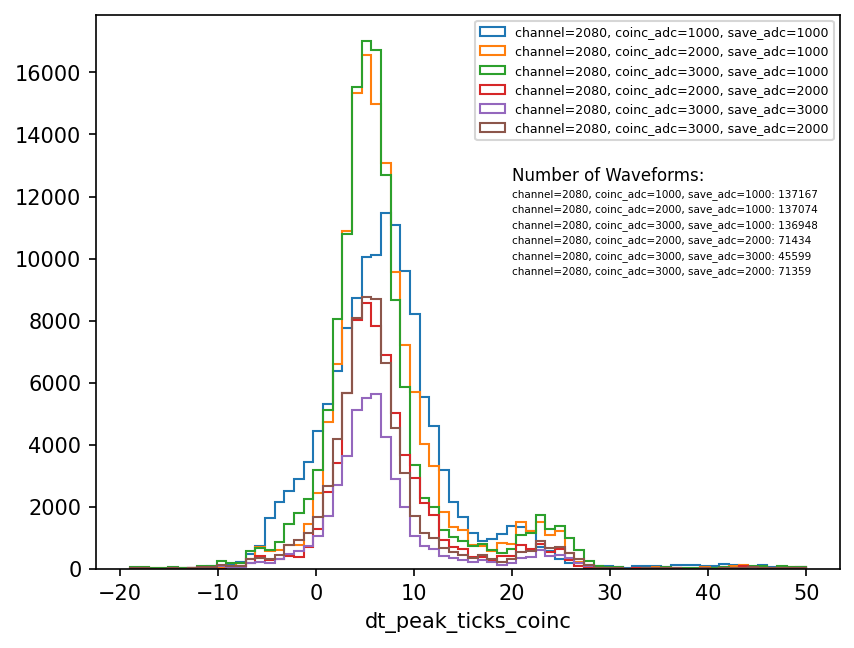

In [36]:
selected_values_1, label_1, xlabel = select_discrimination(
    coinc_adc=1000,
    save_adc=1000,
    channel=2080,
    plot_specs="dt_peak_ticks_coinc",
)
selected_values_2, label_2, _ = select_discrimination(
    coinc_adc=2000,
    save_adc=1000,
    channel=2080,
    plot_specs="dt_peak_ticks_coinc",
)

selected_values_3, label_3, _ = select_discrimination(
    coinc_adc=3000,
    save_adc=1000,
    channel=2080,
    plot_specs="dt_peak_ticks_coinc",
)

selected_values_4, label_4, _ = select_discrimination(
    coinc_adc=2000,
    save_adc=2000,
    channel=2080,
    plot_specs="dt_peak_ticks_coinc",
)

selected_values_5, label_5, _ = select_discrimination(
    coinc_adc=3000,
    save_adc=3000,
    channel=2080,
    plot_specs="dt_peak_ticks_coinc",
)

selected_values_6, label_6, _ = select_discrimination(
    coinc_adc=3000,
    save_adc=2000,
    channel=2080,
    plot_specs="dt_peak_ticks_coinc",
)

value = -20
nbins =70


plt.figure(dpi=150)
plt.hist(selected_values_1[selected_values_1>value], bins=nbins, histtype='step', label=label_1)
plt.hist(selected_values_2[selected_values_2>value], bins=nbins, histtype='step', label=label_2)
plt.hist(selected_values_3[selected_values_3>value], bins=nbins, histtype='step', label=label_3)
plt.hist(selected_values_4[selected_values_4>value], bins=nbins, histtype='step', label=label_4)
plt.hist(selected_values_5[selected_values_5>value], bins=nbins, histtype='step', label=label_5)
plt.hist(selected_values_6[selected_values_6>value], bins=nbins, histtype='step', label=label_6)
plt.text(20,12500,"Number of Waveforms:",fontsize=8)
plt.text(20,12000,rf"{label_1}: {selected_values_1[selected_values_1>value].size}",fontsize=5)
plt.text(20,11500,rf"{label_2}: {selected_values_2[selected_values_2>value].size}",fontsize=5)
plt.text(20,11000,rf"{label_3}: {selected_values_3[selected_values_3>value].size}",fontsize=5)
plt.text(20,10500,rf"{label_4}: {selected_values_4[selected_values_4>value].size}",fontsize=5)
plt.text(20,10000,rf"{label_5}: {selected_values_5[selected_values_5>value].size}",fontsize=5)
plt.text(20,9500,rf"{label_6}: {selected_values_6[selected_values_6>value].size}",fontsize=5)

plt.xlabel(xlabel)
plt.legend(fontsize=6)
plt.show()

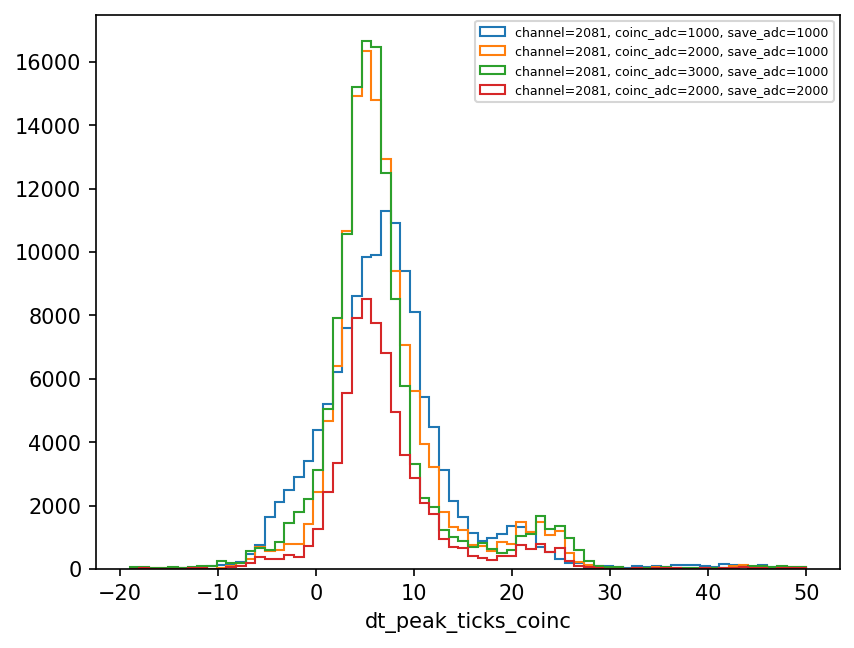

In [ ]:
selected_values_1, label_1, xlabel = select_discrimination(
    coinc_adc=1000,
    save_adc=1000,
    channel=2080,
    plot_specs="dt_peak_ticks_coinc",
)
selected_values_2, label_2, _ = select_discrimination(
    coinc_adc=2000,
    save_adc=1000,
    channel=2080,
    plot_specs="dt_peak_ticks_coinc",
)

selected_values_3, label_3, _ = select_discrimination(
    coinc_adc=3000,
    save_adc=1000,
    channel=2080,
    plot_specs="dt_peak_ticks_coinc",
)

selected_values_4, label_4, _ = select_discrimination(
    coinc_adc=2000,
    save_adc=2000,
    channel=2080,
    plot_specs="dt_peak_ticks_coinc",
)

selected_values_5, label_5, _ = select_discrimination(
    coinc_adc=3000,
    save_adc=3000,
    channel=2080,
    plot_specs="dt_peak_ticks_coinc",
)

selected_values_6, label_6, _ = select_discrimination(
    coinc_adc=3000,
    save_adc=2000,
    channel=2080,
    plot_specs="dt_peak_ticks_coinc",
)

value = -20
nbins =70


plt.figure(dpi=150)
plt.hist(selected_values_1[selected_values_1>value], bins=nbins, histtype='step', label=label_1)
plt.hist(selected_values_2[selected_values_2>value], bins=nbins, histtype='step', label=label_2)
plt.hist(selected_values_3[selected_values_3>value], bins=nbins, histtype='step', label=label_3)
plt.hist(selected_values_4[selected_values_4>value], bins=nbins, histtype='step', label=label_4)
plt.hist(selected_values_5[selected_values_5>value], bins=nbins, histtype='step', label=label_5)
plt.hist(selected_values_6[selected_values_6>value], bins=nbins, histtype='step', label=label_6)
plt.text(20,12500,"Number of Waveforms:",fontsize=8)
plt.text(20,12000,rf"{label_1}: {selected_values_1[selected_values_1>value].size}",fontsize=5)
plt.text(20,11500,rf"{label_2}: {selected_values_2[selected_values_2>value].size}",fontsize=5)
plt.text(20,11000,rf"{label_3}: {selected_values_3[selected_values_3>value].size}",fontsize=5)
plt.text(20,10500,rf"{label_4}: {selected_values_4[selected_values_4>value].size}",fontsize=5)
plt.text(20,10000,rf"{label_5}: {selected_values_5[selected_values_5>value].size}",fontsize=5)
plt.text(20,9500,rf"{label_6}: {selected_values_6[selected_values_6>value].size}",fontsize=5)

plt.xlabel(xlabel)
plt.legend(fontsize=6)
plt.show()

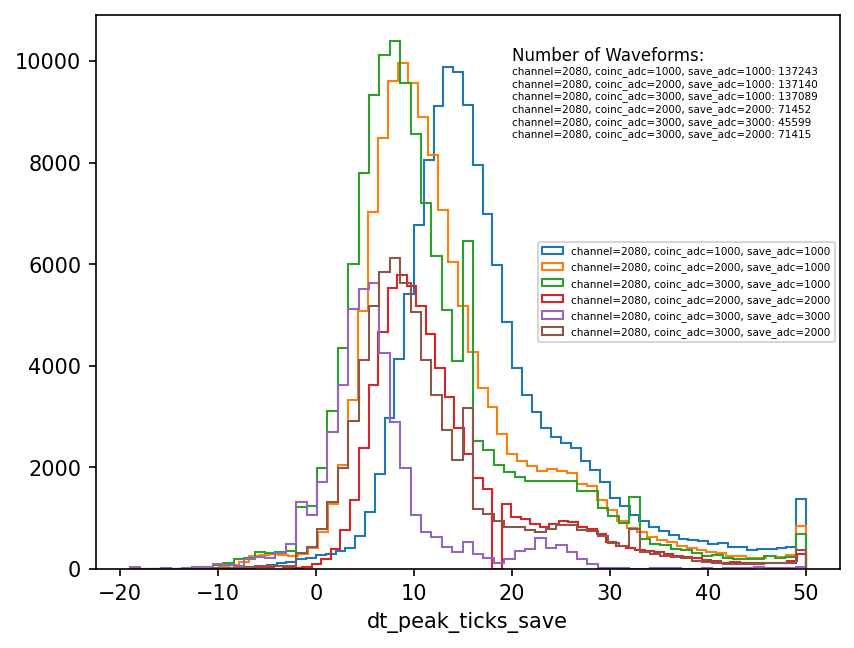

In [ ]:
selected_values_1, label_1, xlabel = select_discrimination(
    coinc_adc=1000,
    save_adc=1000,
    channel=2080,
    plot_specs="dt_peak_ticks_save",
)
selected_values_2, label_2, _ = select_discrimination(
    coinc_adc=2000,
    save_adc=1000,
    channel=2080,
    plot_specs="dt_peak_ticks_save",
)

selected_values_3, label_3, _ = select_discrimination(
    coinc_adc=3000,
    save_adc=1000,
    channel=2080,
    plot_specs="dt_peak_ticks_save",
)

selected_values_4, label_4, _ = select_discrimination(
    coinc_adc=2000,
    save_adc=2000,
    channel=2080,
    plot_specs="dt_peak_ticks_save",
)

selected_values_5, label_5, _ = select_discrimination(
    coinc_adc=3000,
    save_adc=3000,
    channel=2080,
    plot_specs="dt_peak_ticks_coinc",
)

selected_values_6, label_6, _ = select_discrimination(
    coinc_adc=3000,
    save_adc=2000,
    channel=2080,
    plot_specs="dt_peak_ticks_save",
)

value = -20
nbins =65


plt.figure(dpi=150)
plt.hist(selected_values_1[selected_values_1>value], bins=nbins, histtype='step', label=label_1)
plt.hist(selected_values_2[selected_values_2>value], bins=nbins, histtype='step', label=label_2)
plt.hist(selected_values_3[selected_values_3>value], bins=nbins, histtype='step', label=label_3)
plt.hist(selected_values_4[selected_values_4>value], bins=nbins, histtype='step', label=label_4)
plt.hist(selected_values_5[selected_values_5>value], bins=nbins, histtype='step', label=label_5)
plt.hist(selected_values_6[selected_values_6>value], bins=nbins, histtype='step', label=label_6)
plt.text(20,10000,"Number of Waveforms:",fontsize=8)
plt.text(20,9750,rf"{label_1}: {selected_values_1[selected_values_1>value].size}",fontsize=5)
plt.text(20,9500,rf"{label_2}: {selected_values_2[selected_values_2>value].size}",fontsize=5)
plt.text(20,9250,rf"{label_3}: {selected_values_3[selected_values_3>value].size}",fontsize=5)
plt.text(20,9000,rf"{label_4}: {selected_values_4[selected_values_4>value].size}",fontsize=5)
plt.text(20,8750,rf"{label_5}: {selected_values_5[selected_values_5>value].size}",fontsize=5)
plt.text(20,8500,rf"{label_6}: {selected_values_6[selected_values_6>value].size}",fontsize=5)

plt.xlabel(xlabel)
plt.legend(fontsize=5)
plt.show()

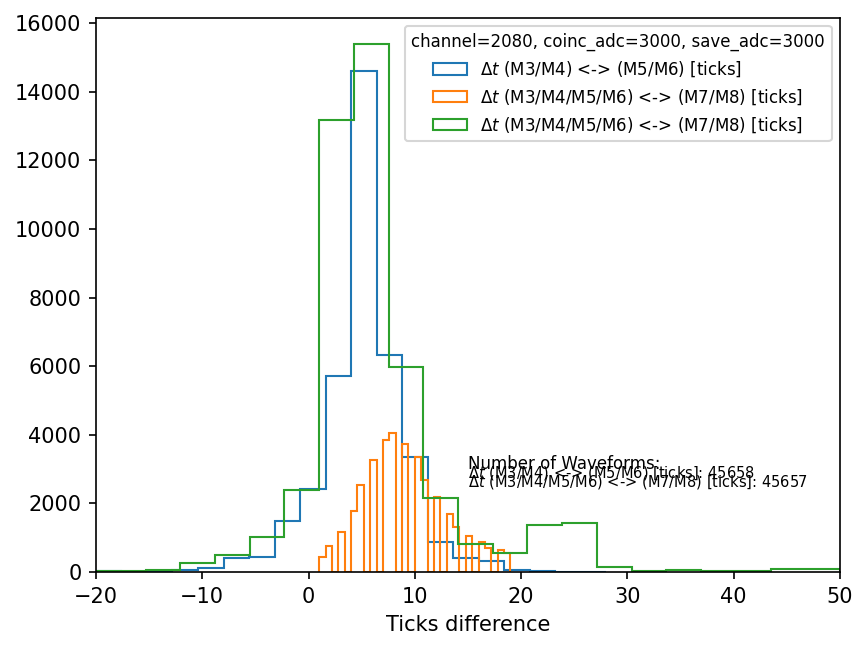

In [92]:
selected_values_3, label_3, _ = select_discrimination(
    coinc_adc=3000,
    save_adc=3000,
    channel=2080,
    plot_specs="dt_peak_ticks_coinc",
)

selected_values_4, label_4, _ = select_discrimination(
    coinc_adc=3000,
    save_adc=3000,
    channel=2080,
    plot_specs="dt_peak_ticks_save",
)

nbins = 30


mask = (selected_values_4 > 0) & (selected_values_4 < 20)

plt.figure(dpi=150)
plt.hist(selected_values_3[mask], bins=nbins, histtype='step', label=r"$\Delta t$ (M3/M4) <-> (M5/M6) [ticks]")
plt.hist(selected_values_4[mask], bins=nbins, histtype='step', label= r"$\Delta t$ (M3/M4/M5/M6) <-> (M7/M8) [ticks]")
plt.hist(selected_values_3, bins=nbins, histtype='step', label= r"$\Delta t$ (M3/M4/M5/M6) <-> (M7/M8) [ticks]")
plt.text(15,3000,"Number of Waveforms:",fontsize=8)
plt.text(15,2750,rf"$\Delta t$ (M3/M4) <-> (M5/M6) [ticks]: {selected_values_3[selected_values_3>value].size}",fontsize=7)
plt.text(15,2500,rf"$\Delta t$ (M3/M4/M5/M6) <-> (M7/M8) [ticks]: {selected_values_4[selected_values_4>value].size}",fontsize=7)
plt.xlim([-20,50])
plt.xlabel("Ticks difference")
plt.legend(title= label_3,fontsize=8, title_fontsize=8)
plt.show()


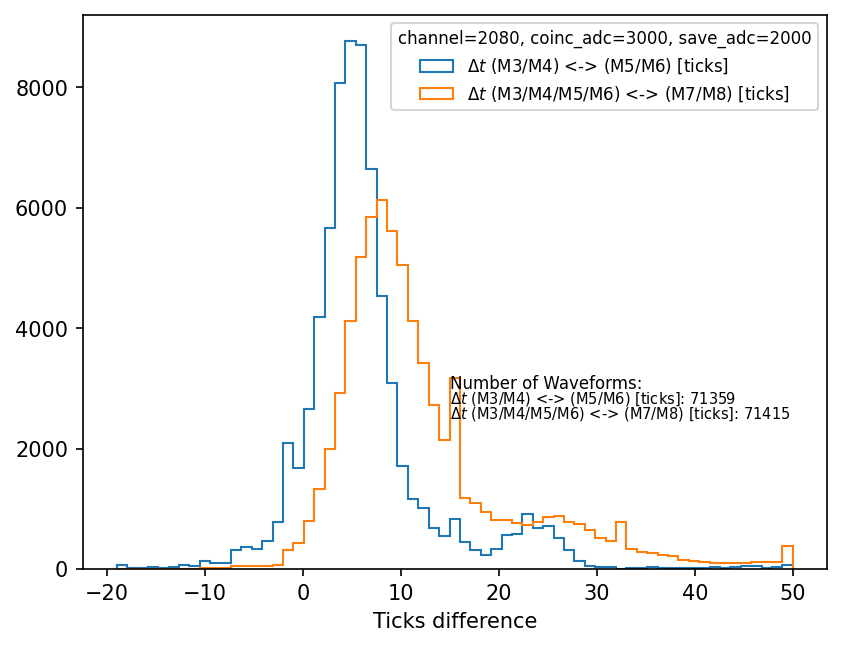

In [79]:
selected_values_3, label_3, _ = select_discrimination(
    coinc_adc=3000,
    save_adc=2000,
    channel=2080,
    plot_specs="dt_peak_ticks_coinc",
)

selected_values_4, label_4, _ = select_discrimination(
    coinc_adc=3000,
    save_adc=2000,
    channel=2080,
    plot_specs="dt_peak_ticks_save",
)

value = -20
nbins = 65

plt.figure(dpi=150)
plt.hist(selected_values_3[selected_values_3>value], bins=nbins, histtype='step', label=r"$\Delta t$ (M3/M4) <-> (M5/M6) [ticks]")
plt.hist(selected_values_4[selected_values_4>value], bins=nbins, histtype='step', label= r"$\Delta t$ (M3/M4/M5/M6) <-> (M7/M8) [ticks]")
plt.text(15,3000,"Number of Waveforms:",fontsize=8)
plt.text(15,2750,rf"$\Delta t$ (M3/M4) <-> (M5/M6) [ticks]: {selected_values_3[selected_values_3>value].size}",fontsize=7)
plt.text(15,2500,rf"$\Delta t$ (M3/M4/M5/M6) <-> (M7/M8) [ticks]: {selected_values_4[selected_values_4>value].size}",fontsize=7)

plt.xlabel("Ticks difference")
plt.legend(title= label_3,fontsize=8, title_fontsize=8)
plt.show()
